# Lab 1: Adult Dataset EDA and Statistical Analysis

## Objective
This notebook solves the Lab 1 assignment using the UCI Adult dataset with code and explanations.

## Hypothesis
The dataset supports binary classification for income prediction: whether a person earns more than \$50K per year.

## What We Will Extract
- Basic data understanding (shape, types, missing values, unique classes)
- Distribution behavior of important numeric columns
- Categorical feature patterns related to income
- One-hot encoded feature matrix for future ML work
- Required statistical metrics and visual comparisons for male/female populations

## Environment Setup
This cell imports required libraries. If `pandas` or `seaborn` are missing, it installs them automatically.

In [1]:
import importlib.util
import subprocess
import sys

required_pkgs = ["pandas", "seaborn"]
for pkg in required_pkgs:
    if importlib.util.find_spec(pkg) is None:
        print(f"Installing missing package: {pkg}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 80)
sns.set_theme(style="whitegrid")

print("Setup complete.")


Setup complete.


## Load Dataset and Define Schema
We load the dataset from the official UCI source and assign explicit column names.

In [2]:
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

column_names = [
    "Age", "WorkClass", "fnlwgt", "Education", "EducationNum", "MaritalStatus",
    "Occupation", "Relationship", "Race", "Gender", "CapitalGain", "CapitalLoss",
    "HoursPerWeek", "NativeCountry", "Income"
]

df_raw = pd.read_csv(DATA_URL, header=None, names=column_names, skipinitialspace=True)

# Trim whitespace in all text columns (works cleanly across pandas 2/3)
for col in df_raw.select_dtypes(include=["object", "string"]).columns:
    df_raw[col] = df_raw[col].str.strip()

print("Loaded dataset successfully")
print("Shape:", df_raw.shape)
print("Columns:", list(df_raw.columns))


Loaded dataset successfully
Shape: (32561, 15)
Columns: ['Age', 'WorkClass', 'fnlwgt', 'Education', 'EducationNum', 'MaritalStatus', 'Occupation', 'Relationship', 'Race', 'Gender', 'CapitalGain', 'CapitalLoss', 'HoursPerWeek', 'NativeCountry', 'Income']


## Initial EDA: Head, Tail, Shape, Data Types

In [3]:
print("Head:")
display(df_raw.head())

print("Tail:")
display(df_raw.tail())

print("Shape:", df_raw.shape)
print()
print("Data types:")
print(df_raw.dtypes)

Head:


,Age,WorkClass,fnlwgt,Education,EducationNum,MaritalStatus,Occupation,Relationship,Race,Gender,CapitalGain,CapitalLoss,HoursPerWeek,NativeCountry,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Tail:


,Age,WorkClass,fnlwgt,Education,EducationNum,MaritalStatus,Occupation,Relationship,Race,Gender,CapitalGain,CapitalLoss,HoursPerWeek,NativeCountry,Income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


Shape: (32561, 15)

Data types:
Age               int64
WorkClass        object
fnlwgt            int64
Education        object
EducationNum      int64
MaritalStatus    object
Occupation       object
Relationship     object
Race             object
Gender           object
CapitalGain       int64
CapitalLoss       int64
HoursPerWeek      int64
NativeCountry    object
Income           object
dtype: object


In [4]:
print("NaN counts per column (before handling '?' tokens):")
print(df_raw.isna().sum())

print()
print("Unique values in Income:")
print(df_raw["Income"].unique())

income_map = {"<=50K": -1, ">50K": 1}
df_raw["IncomeBinary"] = df_raw["Income"].map(income_map)

if df_raw["IncomeBinary"].isna().any():
    bad_values = sorted(df_raw.loc[df_raw["IncomeBinary"].isna(), "Income"].unique())
    raise ValueError(f"Unexpected Income values found: {bad_values}")

y = df_raw["IncomeBinary"].to_numpy(dtype=int)
X_df = df_raw.drop(columns=["Income", "IncomeBinary"]).copy()

print()
print("Income mapping completed.")
print("Unique target labels in y:", np.unique(y))

NaN counts per column (before handling '?' tokens):
Age              0
WorkClass        0
fnlwgt           0
Education        0
EducationNum     0
MaritalStatus    0
Occupation       0
Relationship     0
Race             0
Gender           0
CapitalGain      0
CapitalLoss      0
HoursPerWeek     0
NativeCountry    0
Income           0
dtype: int64

Unique values in Income:
['<=50K' '>50K']

Income mapping completed.
Unique target labels in y: [-1  1]


`y` is now the binary target array with values `{-1, +1}` and `X_df` contains only features.

In [5]:
print("Feature dataframe (X_df) head:")
display(X_df.head())

print("Summary statistics for numeric columns:")
display(X_df.describe())

Feature dataframe (X_df) head:


,Age,WorkClass,fnlwgt,Education,EducationNum,MaritalStatus,Occupation,Relationship,Race,Gender,CapitalGain,CapitalLoss,HoursPerWeek,NativeCountry
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


Summary statistics for numeric columns:


,Age,fnlwgt,EducationNum,CapitalGain,CapitalLoss,HoursPerWeek
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## Sparse-Value Analysis for CapitalGain and CapitalLoss
The assignment asks whether these are heavily concentrated at zero.

In [6]:
capital_gain_zero_pct = (df_raw["CapitalGain"] == 0).mean() * 100
capital_loss_zero_pct = (df_raw["CapitalLoss"] == 0).mean() * 100

print(f"CapitalGain % zeros: {capital_gain_zero_pct:.2f}%")
print(f"CapitalLoss % zeros: {capital_loss_zero_pct:.2f}%")

CapitalGain % zeros: 91.67%
CapitalLoss % zeros: 95.33%


Both columns are highly sparse in this dataset (large mass at zero), which can create wide but mostly-empty feature representations.
As requested, we drop both columns before later encoding.

In [7]:
df_sparse_dropped = df_raw.drop(columns=["CapitalGain", "CapitalLoss", "IncomeBinary"]).copy()

print("Shape after dropping CapitalGain and CapitalLoss:", df_sparse_dropped.shape)
print("Remaining columns:")
print(df_sparse_dropped.columns.tolist())

Shape after dropping CapitalGain and CapitalLoss: (32561, 13)
Remaining columns:
['Age', 'WorkClass', 'fnlwgt', 'Education', 'EducationNum', 'MaritalStatus', 'Occupation', 'Relationship', 'Race', 'Gender', 'HoursPerWeek', 'NativeCountry', 'Income']


## Categorical Variable Exploration
Required categorical columns:
- WorkClass, Education, MaritalStatus, Occupation, Relationship, Race, Gender, NativeCountry

In [8]:
categorical_cols = [
    "WorkClass", "Education", "MaritalStatus", "Occupation",
    "Relationship", "Race", "Gender", "NativeCountry"
]

for col in categorical_cols:
    print()
    print(f"{col} unique values:")
    print(sorted(df_sparse_dropped[col].dropna().unique().tolist()))


WorkClass unique values:
['?', 'Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay']

Education unique values:
['10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th', 'Assoc-acdm', 'Assoc-voc', 'Bachelors', 'Doctorate', 'HS-grad', 'Masters', 'Preschool', 'Prof-school', 'Some-college']

MaritalStatus unique values:
['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed']

Occupation unique values:
['?', 'Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Other-service', 'Priv-house-serv', 'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving']

Relationship unique values:
['Husband', 'Not-in-family', 'Other-relative', 'Own-child', 'Unmarried', 'Wife']

Race unique values:
['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'White']

Gend

In [9]:
df_clean = df_sparse_dropped.copy()

# Convert '?' placeholders to missing values, then drop rows containing missing categorical values.
df_clean[categorical_cols] = df_clean[categorical_cols].replace("?", np.nan)

rows_before = len(df_clean)
missing_before_drop = df_clean[categorical_cols].isna().sum().sort_values(ascending=False)

df_clean = df_clean.dropna(subset=categorical_cols).copy()
rows_after = len(df_clean)

print("Missing counts in categorical columns before drop:")
print(missing_before_drop)
print()
print("Rows before drop:", rows_before)
print("Rows after drop:", rows_after)
print("Rows removed:", rows_before - rows_after)

Missing counts in categorical columns before drop:
Occupation       1843
WorkClass        1836
NativeCountry     583
Education           0
MaritalStatus       0
Relationship        0
Race                0
Gender              0
dtype: int64

Rows before drop: 32561
Rows after drop: 30162
Rows removed: 2399


In [10]:
distinct_counts = (
    df_clean[categorical_cols]
    .nunique()
    .rename("DistinctCount")
    .sort_values(ascending=False)
    .to_frame()
)

print("Distinct count of each categorical column:")
display(distinct_counts)

Distinct count of each categorical column:


,DistinctCount
NativeCountry,41
Education,16
Occupation,14
WorkClass,7
MaritalStatus,7
Relationship,6
Race,5
Gender,2


In [11]:
# Category-level income tendency (share of >50K) for each categorical feature.
# Use a minimum category size filter to avoid very noisy tiny groups.
MIN_GROUP_SIZE = 50

for col in categorical_cols:
    temp = (
        df_clean.groupby(col)["Income"]
        .agg(
            Count="count",
            HighIncomeRate=lambda s: (s == ">50K").mean() * 100,
        )
        .sort_values("HighIncomeRate", ascending=False)
    )
    temp = temp[temp["Count"] >= MIN_GROUP_SIZE]

    print()
    print(f"{col} - top categories by >50K rate (Count >= {MIN_GROUP_SIZE}):")
    display(temp.head(8))


WorkClass - top categories by >50K rate (Count >= 50):


,Count,HighIncomeRate
WorkClass,,
Self-emp-inc,1074,55.865922
Federal-gov,943,38.706257
Local-gov,2067,29.462990
Self-emp-not-inc,2499,28.571429
State-gov,1279,26.896013
Private,22286,21.879207



Education - top categories by >50K rate (Count >= 50):


,Count,HighIncomeRate
Education,,
Prof-school,542,74.907749
Doctorate,375,74.666667
Masters,1627,56.422864
Bachelors,5044,42.149088
Assoc-voc,1307,26.319816
Assoc-acdm,1008,25.396825
Some-college,6678,20.005990
HS-grad,9840,16.432927



MaritalStatus - top categories by >50K rate (Count >= 50):


...

,Count,HighIncomeRate
Race,,
Asian-Pac-Islander,895,27.709497
White,25933,26.371804
Black,2817,12.992545
Amer-Indian-Eskimo,286,11.888112
Other,231,9.090909



Gender - top categories by >50K rate (Count >= 50):


,Count,HighIncomeRate
Gender,,
Male,20380,31.383710
Female,9782,11.367818



NativeCountry - top categories by >50K rate (Count >= 50):


,Count,HighIncomeRate
NativeCountry,,
India,100,40.000000
Japan,59,38.983051
Italy,68,35.294118
England,86,34.883721
Germany,128,34.375000
Canada,107,33.644860
Philippines,188,31.914894
China,68,29.411765


### Categorical Analysis Notes (w.r.t. Hypothesis)
- `Education` and `Occupation` usually show strong separation in the `>50K` rate.
- `MaritalStatus` and `Relationship` often have noticeable income distribution differences.
- `Gender` comparison is central to the assignment and is analyzed again in dedicated metric/plot sections.
- `NativeCountry` can have many levels; larger groups are more reliable than tiny groups.

## One-Hot Encoding
Now we encode all categorical columns for model-ready numerical features.

In [12]:
features_for_encoding = df_clean.drop(columns=["Income"]).copy()

encoded_df = pd.get_dummies(
    features_for_encoding,
    columns=categorical_cols,
    drop_first=False,
    dtype=int,
)

print("Encoded dataframe shape:", encoded_df.shape)
print("Preview:")
display(encoded_df.head())

Encoded dataframe shape: (30162, 102)
Preview:


,Age,fnlwgt,EducationNum,HoursPerWeek,WorkClass_Federal-gov,WorkClass_Local-gov,WorkClass_Private,WorkClass_Self-emp-inc,WorkClass_Self-emp-not-inc,WorkClass_State-gov,WorkClass_Without-pay,Education_10th,Education_11th,Education_12th,Education_1st-4th,Education_5th-6th,Education_7th-8th,Education_9th,Education_Assoc-acdm,Education_Assoc-voc,Education_Bachelors,Education_Doctorate,Education_HS-grad,Education_Masters,Education_Preschool,Education_Prof-school,Education_Some-college,MaritalStatus_Divorced,MaritalStatus_Married-AF-spouse,MaritalStatus_Married-civ-spouse,MaritalStatus_Married-spouse-absent,MaritalStatus_Never-married,MaritalStatus_Separated,MaritalStatus_Widowed,Occupation_Adm-clerical,Occupation_Armed-Forces,Occupation_Craft-repair,Occupation_Exec-managerial,Occupation_Farming-fishing,Occupation_Handlers-cleaners,Occupation_Machine-op-inspct,Occupation_Other-service,Occupation_Priv-house-serv,Occupation_Prof-specialty,Occupation_Protective-serv,Occupation_Sales,Occupation_Tech-support,Occupation_Transport-moving,Relationship_Husband,Relationship_Not-in-family,Relationship_Other-relative,Relationship_Own-child,Relationship_Unmarried,Relationship_Wife,Race_Amer-Indian-Eskimo,Race_Asian-Pac-Islander,Race_Black,Race_Other,Race_White,Gender_Female,Gender_Male,NativeCountry_Cambodia,NativeCountry_Canada,NativeCountry_China,NativeCountry_Columbia,NativeCountry_Cuba,NativeCountry_Dominican-Republic,NativeCountry_Ecuador,NativeCountry_El-Salvador,NativeCountry_England,NativeCountry_France,NativeCountry_Germany,NativeCountry_Greece,NativeCountry_Guatemala,NativeCountry_Haiti,NativeCountry_Holand-Netherlands,NativeCountry_Honduras,NativeCountry_Hong,NativeCountry_Hungary,NativeCountry_India,NativeCountry_Iran,NativeCountry_Ireland,NativeCountry_Italy,NativeCountry_Jamaica,NativeCountry_Japan,NativeCountry_Laos,NativeCountry_Mexico,NativeCountry_Nicaragua,NativeCountry_Outlying-US(Guam-USVI-etc),NativeCountry_Peru,NativeCountry_Philippines,NativeCountry_Poland,NativeCountry_Portugal,NativeCountry_Puerto-Rico,NativeCountry_Scotland,NativeCountry_South,NativeCountry_Taiwan,NativeCountry_Thailand,NativeCountry_Trinadad&Tobago,NativeCountry_United-States,NativeCountry_Vietnam,NativeCountry_Yugoslavia
0,39,77516,13,40,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,50,83311,13,13,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,38,215646,9,40,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,53,234721,7,40,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,28,338409,13,40,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Required Metrics (Male/Female and Income)
The following block computes all required assignment statistics.

In [13]:
male_df = df_clean[df_clean["Gender"] == "Male"].copy()
female_df = df_clean[df_clean["Gender"] == "Female"].copy()

male_total = len(male_df)
female_total = len(female_df)

male_gt_50k = (male_df["Income"] == ">50K").sum()
female_gt_50k = (female_df["Income"] == ">50K").sum()

avg_age_male_gt_50k = male_df.loc[male_df["Income"] == ">50K", "Age"].mean()
avg_age_female_le_50k = female_df.loc[female_df["Income"] == "<=50K", "Age"].mean()

std_male_age = male_df["Age"].std()
std_female_age = female_df["Age"].std()

skew_male_age = male_df["Age"].skew()
skew_female_age = female_df["Age"].skew()

mean_age_diff = male_df["Age"].mean() - female_df["Age"].mean()

metrics = pd.DataFrame(
    {
        "Metric": [
            "Total male count",
            "Total female count",
            "Male count with income >50K",
            "Female count with income >50K",
            "Average age of males with income >50K",
            "Average age of females with income <=50K",
            "Std. deviation of male age",
            "Std. deviation of female age",
            "Skewness of male age",
            "Skewness of female age",
            "Mean age difference (male - female)",
        ],
        "Value": [
            male_total,
            female_total,
            male_gt_50k,
            female_gt_50k,
            avg_age_male_gt_50k,
            avg_age_female_le_50k,
            std_male_age,
            std_female_age,
            skew_male_age,
            skew_female_age,
            mean_age_diff,
        ],
    }
)

print("Required metrics:")
display(metrics)

Required metrics:


,Metric,Value
0,Total male count,20380.000000
1,Total female count,9782.000000
2,Male count with income >50K,6396.000000
3,Female count with income >50K,1112.000000
4,Average age of males with income >50K,44.305816
5,Average age of females with income <=50K,36.231719
6,Std. deviation of male age,12.873243
7,Std. deviation of female age,13.532427
8,Skewness of male age,0.501316
9,Skewness of female age,0.629886


The table above directly answers the numeric checklist from the assignment.

## Visual Analysis
We now produce the required and supporting plots.

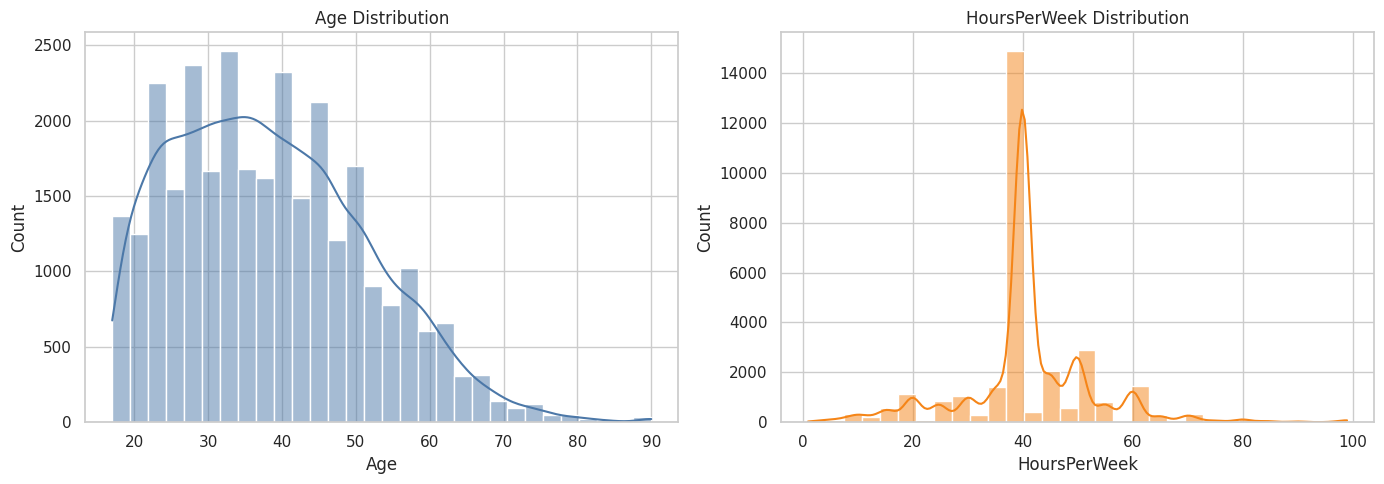

/tmp/ipykernel_9328/2591391597.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x="Income", ax=axes[0], palette="Set2")
/tmp/ipykernel_9328/2591391597.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x="Gender", ax=axes[1], palette="Set1")


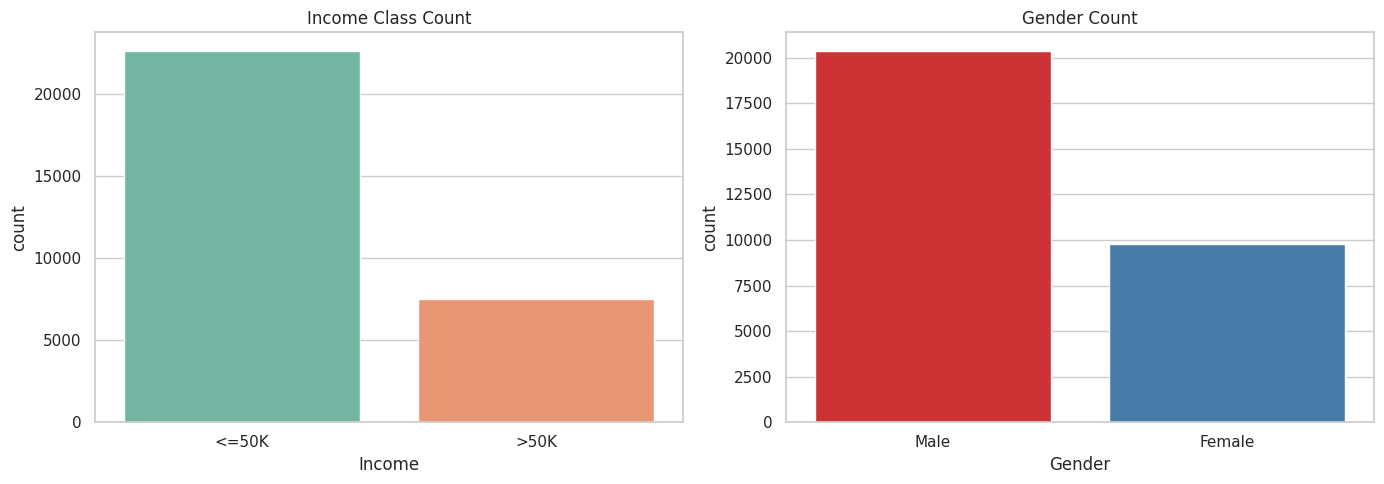

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean["Age"], bins=30, kde=True, ax=axes[0], color="#4C78A8")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")

sns.histplot(df_clean["HoursPerWeek"], bins=30, kde=True, ax=axes[1], color="#F58518")
axes[1].set_title("HoursPerWeek Distribution")
axes[1].set_xlabel("HoursPerWeek")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_clean, x="Income", ax=axes[0], palette="Set2")
axes[0].set_title("Income Class Count")

sns.countplot(data=df_clean, x="Gender", ax=axes[1], palette="Set1")
axes[1].set_title("Gender Count")

plt.tight_layout()
plt.show()

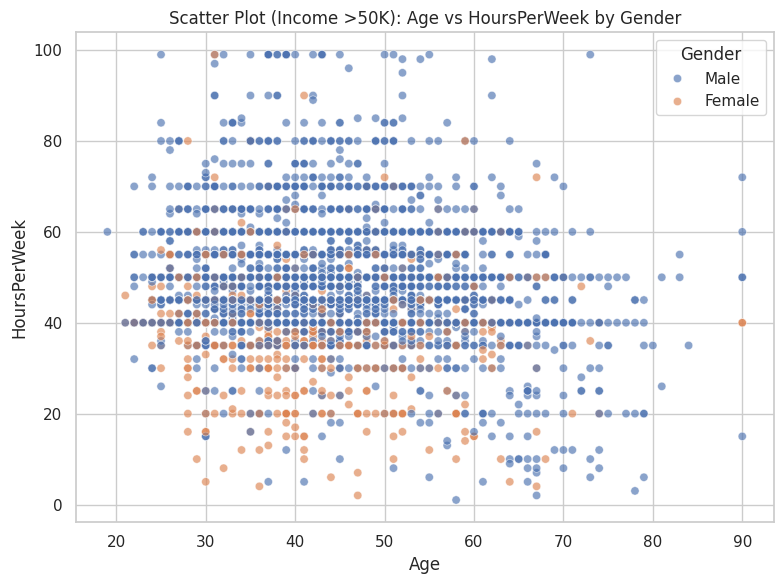

In [15]:
high_income_df = df_clean[df_clean["Income"] == ">50K"].copy()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=high_income_df,
    x="Age",
    y="HoursPerWeek",
    hue="Gender",
    alpha=0.65,
)
plt.title("Scatter Plot (Income >50K): Age vs HoursPerWeek by Gender")
plt.xlabel("Age")
plt.ylabel("HoursPerWeek")
plt.tight_layout()
plt.show()

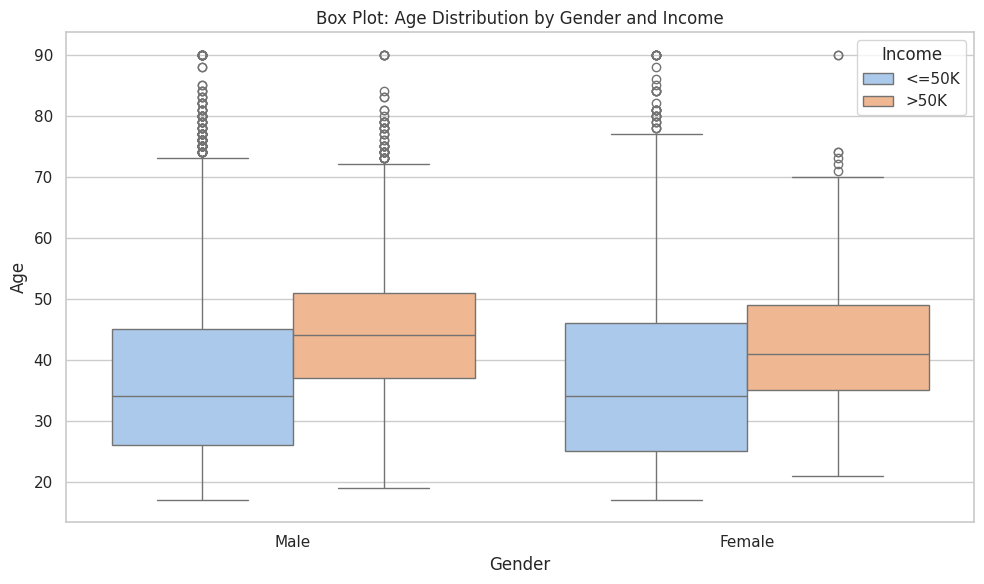

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x="Gender", y="Age", hue="Income", palette="pastel")
plt.title("Box Plot: Age Distribution by Gender and Income")
plt.xlabel("Gender")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

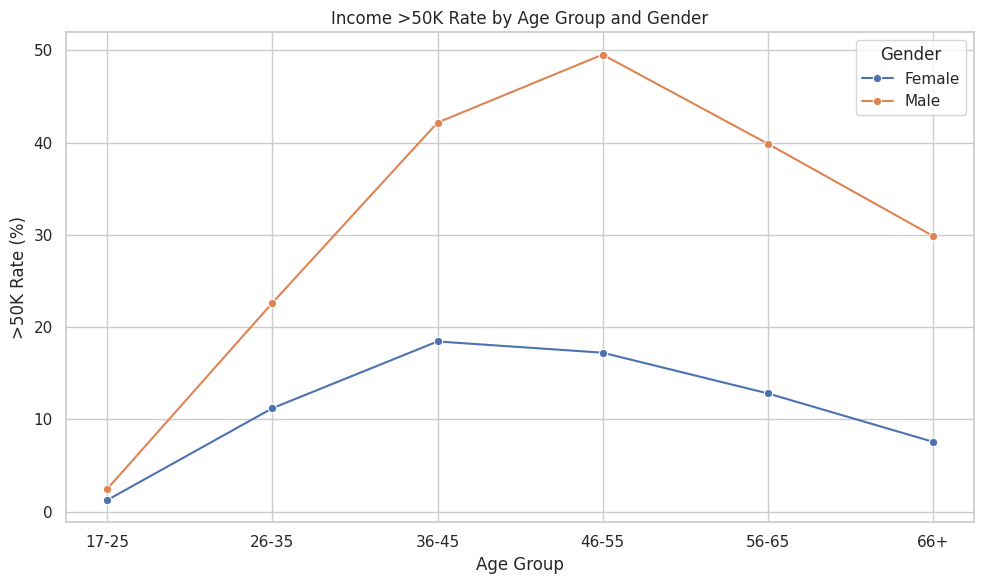

In [17]:
age_bins = [16, 25, 35, 45, 55, 65, 100]
age_labels = ["17-25", "26-35", "36-45", "46-55", "56-65", "66+"]

line_df = df_clean.copy()
line_df["AgeBin"] = pd.cut(
    line_df["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True,
)

income_rate_by_age_gender = (
    line_df.groupby(["AgeBin", "Gender"], observed=False)["Income"]
    .apply(lambda s: (s == ">50K").mean() * 100)
    .reset_index(name="HighIncomeRatePct")
)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=income_rate_by_age_gender,
    x="AgeBin",
    y="HighIncomeRatePct",
    hue="Gender",
    marker="o",
)
plt.title("Income >50K Rate by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel(">50K Rate (%)")
plt.tight_layout()
plt.show()

## Conclusion
- The notebook confirms the Adult dataset is suitable for binary income analysis (`<=50K` vs `>50K`).
- We completed full EDA, handled sparse and missing categorical values, and prepared one-hot encoded features.
- Required male/female counts, means, standard deviations, skewness, and mean age difference were computed.
- Visualizations highlight distribution and income-pattern differences by gender and age.

### Limitations
- This is observational census data; associations do not imply causation.
- Rows with `?` in categorical variables were dropped, which can shift distributions.
- No model training is included here by design; the notebook is now ready for the machine-learning phase.